In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/playground-series-s4e9/sample_submission.csv
/kaggle/input/playground-series-s4e9/train.csv
/kaggle/input/playground-series-s4e9/test.csv


✅ Train shape: (188533, 13)
✅ Test shape: (125690, 12)

Columns: ['id', 'brand', 'model', 'model_year', 'milage', 'fuel_type', 'engine', 'transmission', 'ext_col', 'int_col', 'accident', 'clean_title', 'price']

Train Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 188533 entries, 0 to 188532
Data columns (total 13 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   id            188533 non-null  int64 
 1   brand         188533 non-null  object
 2   model         188533 non-null  object
 3   model_year    188533 non-null  int64 
 4   milage        188533 non-null  int64 
 5   fuel_type     183450 non-null  object
 6   engine        188533 non-null  object
 7   transmission  188533 non-null  object
 8   ext_col       188533 non-null  object
 9   int_col       188533 non-null  object
 10  accident      186081 non-null  object
 11  clean_title   167114 non-null  object
 12  price         188533 non-null  int64 
dtypes: int64(4

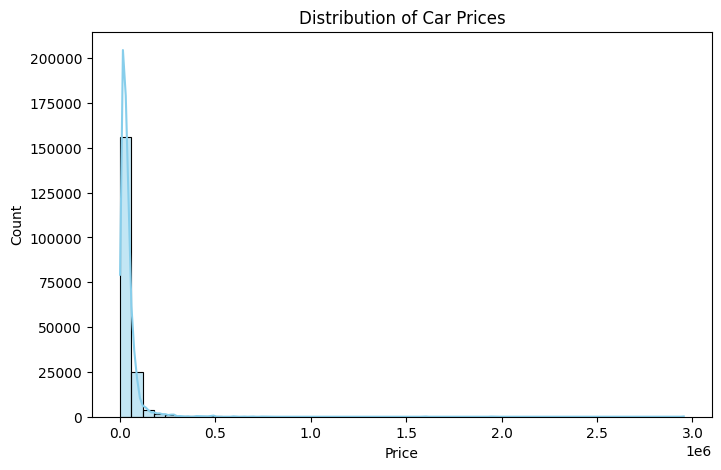

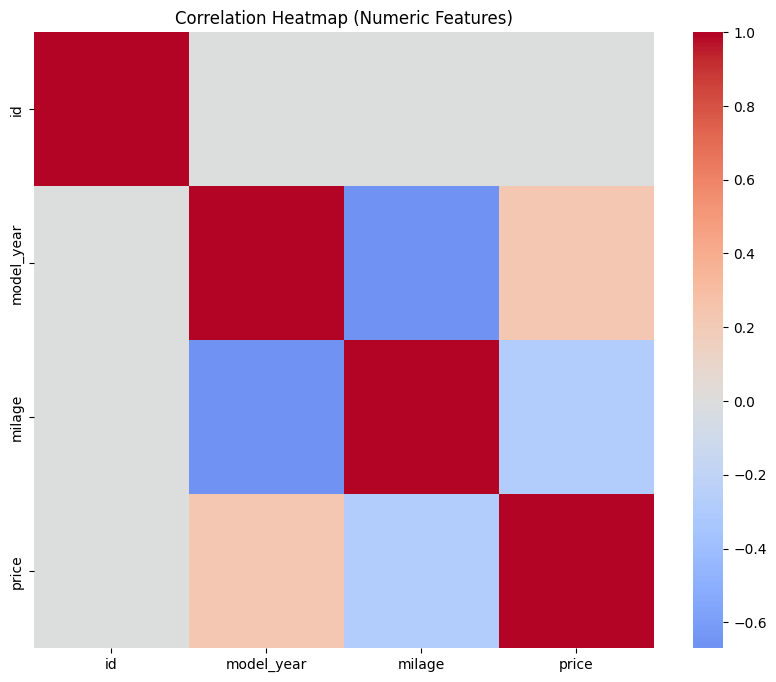

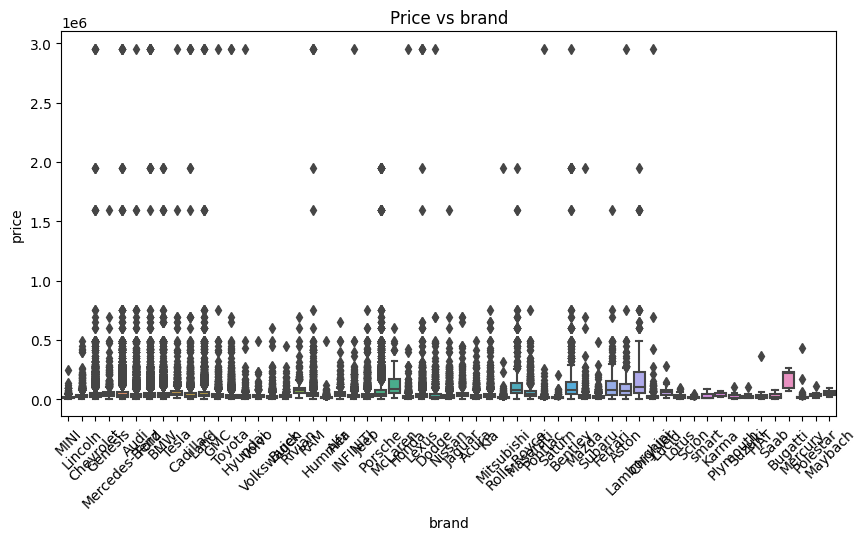


===== Fold 1 =====
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.010543 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1258
[LightGBM] [Info] Number of data points in the train set: 150826, number of used features: 11
[LightGBM] [Info] Start training from score 43890.785316
Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[200]	training's rmse: 71570.3	valid_1's rmse: 67915.5
Fold 1 RMSE: 67915.5188

===== Fold 2 =====
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.011105 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1256
[LightGBM] [Info] Number of data points in the train set: 150826, number of used features: 11
[LightGBM] [Info] Start training from score 43919.862106
Training until validation scores don't improve for 200 rounds
Early stopping, best iterati

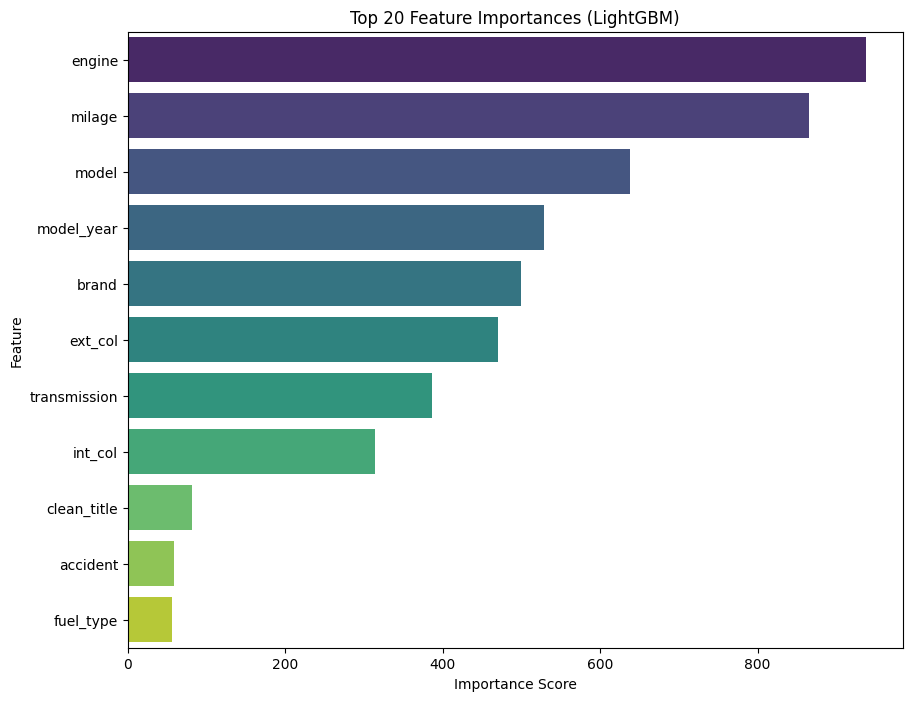


🎉 submission.csv file has been created successfully!


In [2]:
# ============================================================
# 📘 Regression of Used Car Prices - Full Kaggle Notebook
# Includes EDA, Visualizations, Model, and Submission
# ============================================================

# Step 1: Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings("ignore")

# ============================================================
# Step 2: Load Dataset
# ============================================================

train = pd.read_csv("/kaggle/input/playground-series-s4e9/train.csv")
test = pd.read_csv("/kaggle/input/playground-series-s4e9/test.csv")
submission = pd.read_csv("/kaggle/input/playground-series-s4e9/sample_submission.csv")

print("✅ Train shape:", train.shape)
print("✅ Test shape:", test.shape)
print("\nColumns:", train.columns.tolist())

# ============================================================
# Step 3: Quick Data Overview
# ============================================================

print("\nTrain Data Info:")
print(train.info())

print("\nMissing values in Train:")
print(train.isnull().sum()[train.isnull().sum() > 0])

# ============================================================
# Step 4: EDA (Exploratory Data Analysis)
# ============================================================

# --- 4.1 Distribution of Target Variable ---
plt.figure(figsize=(8,5))
sns.histplot(train['price'], bins=50, kde=True, color='skyblue')
plt.title("Distribution of Car Prices")
plt.xlabel("Price")
plt.ylabel("Count")
plt.show()

# --- 4.2 Numeric Columns Correlation ---
numeric_cols = train.select_dtypes(include=['int64','float64']).columns
plt.figure(figsize=(10,8))
corr = train[numeric_cols].corr()
sns.heatmap(corr, cmap="coolwarm", center=0, annot=False)
plt.title("Correlation Heatmap (Numeric Features)")
plt.show()

# --- 4.3 Top Categorical Feature Example ---
cat_cols = train.select_dtypes(include='object').columns
if len(cat_cols) > 0:
    plt.figure(figsize=(10,5))
    sns.boxplot(x=cat_cols[0], y='price', data=train)
    plt.title(f"Price vs {cat_cols[0]}")
    plt.xticks(rotation=45)
    plt.show()

# ============================================================
# Step 5: Data Preprocessing
# ============================================================

# Drop ID column if exists
if 'id' in train.columns:
    train.drop('id', axis=1, inplace=True)
    test.drop('id', axis=1, inplace=True)

TARGET = 'price'

# Fill missing values
train.fillna(-999, inplace=True)
test.fillna(-999, inplace=True)

# Label Encode categorical columns
cat_cols = train.select_dtypes(include=['object']).columns
for col in cat_cols:
    le = LabelEncoder()
    full_data = pd.concat([train[col], test[col]], axis=0).astype(str)
    le.fit(full_data)
    train[col] = le.transform(train[col].astype(str))
    test[col] = le.transform(test[col].astype(str))

# Separate features and target
X = train.drop(TARGET, axis=1)
y = train[TARGET]

# ============================================================
# Step 6: Train LightGBM Model with Cross Validation
# ============================================================

kf = KFold(n_splits=5, shuffle=True, random_state=42)
models = []
oof = np.zeros(len(train))
preds = np.zeros(len(test))

for fold, (tr_idx, val_idx) in enumerate(kf.split(X, y)):
    print(f"\n===== Fold {fold + 1} =====")
    X_train, X_val = X.iloc[tr_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[tr_idx], y.iloc[val_idx]

    lgb_train = lgb.Dataset(X_train, y_train)
    lgb_val = lgb.Dataset(X_val, y_val)

    params = {
        'objective': 'regression',
        'metric': 'rmse',
        'boosting_type': 'gbdt',
        'learning_rate': 0.03,
        'num_leaves': 31,
        'max_depth': -1,
        'subsample': 0.8,
        'colsample_bytree': 0.8,
        'random_state': 42,
        'n_estimators': 5000
    }

    model = lgb.train(
        params,
        lgb_train,
        valid_sets=[lgb_train, lgb_val],
        callbacks=[
            lgb.early_stopping(stopping_rounds=200),
            lgb.log_evaluation(500)
        ]
    )

    oof[val_idx] = model.predict(X_val, num_iteration=model.best_iteration)
    preds += model.predict(test, num_iteration=model.best_iteration) / kf.n_splits
    models.append(model)

    rmse = mean_squared_error(y_val, oof[val_idx], squared=False)
    print(f"Fold {fold + 1} RMSE: {rmse:.4f}")

# ============================================================
# Step 7: Evaluation and Feature Importance
# ============================================================

cv_rmse = mean_squared_error(y, oof, squared=False)
print(f"\n✅ Overall CV RMSE: {cv_rmse:.4f}")

# --- Feature Importance ---
importances = pd.DataFrame({
    'feature': X.columns,
    'importance': np.mean([model.feature_importance() for model in models], axis=0)
}).sort_values(by='importance', ascending=False)

plt.figure(figsize=(10,8))
sns.barplot(y='feature', x='importance', data=importances.head(20), palette="viridis")
plt.title("Top 20 Feature Importances (LightGBM)")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.show()

# ============================================================
# Step 8: Submission
# ============================================================

submission['price'] = preds
submission.to_csv("submission.csv", index=False)
print("\n🎉 submission.csv file has been created successfully!")
